## Requirements to run this notebook standalone

Place these two files in the same folder as this notebook before running:
- `smartcare_ai_dataset_1000.csv`
- `smartcare_ai_dataset_data_dictionary.csv`

This notebook covers **Task 02 (Dataset Understanding)** and **Task 03 (Data Preprocessing and Feature Engineering)**. Run all cells top to bottom. It produces the files used by the later task notebooks: `X_train.csv`, `X_test.csv`, `X_train_scaled.csv`, `X_test_scaled.csv`, `y_train.csv`, `y_test.csv`, and `model_df.csv`.

## SmartCare Hospital AI Dataset — Patient Readmission Prediction (30 days)

This notebook covers **Task 02 (Dataset Understanding)** and **Task 03 (Data Preprocessing and Feature Engineering)**:

**Task 02**
1. Explore the dataset
2. Identify input and target variables
3. Explain attribute meanings using data dictionary
4. Discuss data quality

**Task 03**
1. Missing value handling
2. Duplicate record detection
3. Outlier identification
4. Data cleaning
5. Feature engineering
6. Feature selection
7. Feature encoding
8. Feature scaling
9. Train/test split and export of the model-ready dataset

# **Task 02 — Dataset Understanding**

## 2.1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## 2.2. Import the Dataset

In [2]:
df1 = pd.read_csv('../data/raw/smartcare_ai_dataset_1000.csv')
data_dict = pd.read_csv('../data/raw/smartcare_ai_dataset_data_dictionary.csv')
print(df1.shape)
df1.head(10)

(1000, 33)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,...,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,...,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,...,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,...,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,...,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,...,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium
5,6,P10006,50,Female,A+,Neurology,Back Pain,2025-10-13,43,1,...,2500,45000,0,10251,57751,Unpaid,Card,1,1,Medium
6,7,P10007,21,Female,AB-,General Medicine,Fracture,2025-04-23,11,4,...,1500,0,6000,11947,19447,Paid,Card,0,0,Medium
7,8,P10008,64,Female,A-,Cardiology,Fracture,2025-07-06,32,3,...,4000,0,7500,6034,17534,Unpaid,Card,0,0,Medium
8,9,P10009,53,Male,B-,Pediatrics,Kidney Infection,2025-06-09,11,4,...,3000,0,2500,10137,15637,Partially Paid,Online,1,0,Medium
9,10,P10010,51,Male,AB-,Pediatrics,Hypertension,2025-06-18,34,4,...,2500,0,6000,2193,10693,Paid,Card,0,0,Medium


In [3]:
print("\nColumn Names:")
print(df1.columns)


Column Names:
Index(['record_id', 'patient_id', 'age', 'gender', 'blood_group', 'department',
       'diagnosis', 'appointment_date', 'waiting_days',
       'previous_appointments', 'missed_previous_appointments',
       'appointment_status', 'admitted', 'room_type', 'length_of_stay_days',
       'previous_admissions', 'systolic_bp', 'diastolic_bp',
       'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count',
       'treatments_count', 'consultation_fee_lkr', 'room_charge_lkr',
       'lab_charge_lkr', 'medicine_charge_lkr', 'total_bill_lkr',
       'payment_status', 'payment_method', 'no_show', 'readmitted_30_days',
       'disease_risk_level'],
      dtype='str')


## 2.3. Datset Overview

In [4]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     1000 non-null   int64  
 1   patient_id                    1000 non-null   str    
 2   age                           1000 non-null   int64  
 3   gender                        1000 non-null   str    
 4   blood_group                   1000 non-null   str    
 5   department                    1000 non-null   str    
 6   diagnosis                     1000 non-null   str    
 7   appointment_date              1000 non-null   str    
 8   waiting_days                  1000 non-null   int64  
 9   previous_appointments         1000 non-null   int64  
 10  missed_previous_appointments  1000 non-null   int64  
 11  appointment_status            1000 non-null   str    
 12  admitted                      1000 non-null   int64  
 13  room_type      

In [5]:
df1.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
record_id,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
patient_id,1000,1000,P10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,44.744,17.851474,1.0,33.0,44.0,57.0,90.0
gender,1000,2,Male,501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
blood_group,1000,8,AB-,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,1000,7,General Medicine,159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diagnosis,1000,10,Pneumonia,115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_date,1000,339,2025-08-08,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
waiting_days,1000.0,NaN,NaN,NaN,21.851,13.040892,0.0,11.0,22.0,34.0,44.0
previous_appointments,1000.0,NaN,NaN,NaN,2.884,1.693343,0.0,2.0,3.0,4.0,10.0


## 2.4. **Summer of the data overview**

1,000 rows, 33 columns where one row describes one patient appointment.

**record_id** and **patient_id** are unique row identifiers.

Columns span five natural groups:

##### **demographics**

*   age
*   gender
*   blood_group

##### **appointment/admission history**

*   department
*   diagnosis
*   appointment_date
*   waiting_days
*   previouse_appointment
*   missed_previous_appointments
*   appointment_status
*   admitted
*   room_type
*   length_of_stay_days
*   previous_admissions

##### **clinical measurements**

*   systolic_bp
*   diastolic_bp
*   blood_sugar_mg_dl
*   cholesterol_mg_dl
*   bmi
*   lab_tests_count
*   treatments_count

##### **Financial data**

*   consultation_fee_lkr
*   room_charge_lkr
*   lab_charge_lkr
*   medicine_charge_lkr
*   total_bill_lkr
*   payment_status
*   payment_method

##### **prediction targets**

*   no_show
*   readmitted_30_days
*   disease_risk_level



**Selected prediction target - readmitted_30_days**

## 2.5. Checking for the Distribution of Readmitted Prediction

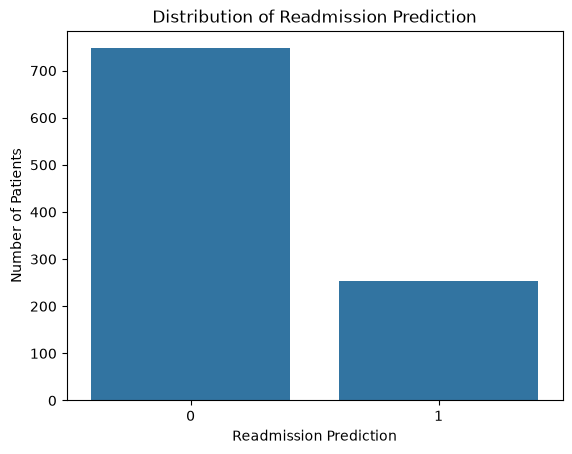

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='readmitted_30_days', data=df1)

plt.title('Distribution of Readmission Prediction')
plt.xlabel('Readmission Prediction')
plt.ylabel('Number of Patients')
plt.show()

In [7]:
class_counts = df1['readmitted_30_days'].value_counts()
class_percentages = df1['readmitted_30_days'].value_counts(normalize=True) * 100

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages)

imbalance_ratio = class_counts.min() / class_counts.max()

print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")

Class Counts:
readmitted_30_days
0    747
1    253
Name: count, dtype: int64

Class Percentages:
readmitted_30_days
0    74.7
1    25.3
Name: proportion, dtype: float64

Imbalance Ratio: 0.34


This is a imbalanced dataset because in readmitted_30_days column, for yes(1) there are only 25.3% and for not admitted (0) there are 74.7% records.

## 2.6. Attribute Description Using Data Dictionary

In [8]:
attr_desc = data_dict.copy()
attr_desc['dtype'] = attr_desc['Column'].map(df1.dtypes.astype(str))
attr_desc

,Column,Description,dtype
0,record_id,Unique row identifier,int64
1,patient_id,Synthetic patient identifier,str
2,age,Patient age in years,int64
3,gender,Patient gender,str
4,blood_group,Patient blood group,str
5,department,Hospital department,str
6,diagnosis,Primary diagnosis category,str
7,appointment_date,Appointment date,str
8,waiting_days,Number of days between booking and appointment,int64
9,previous_appointments,Number of previous appointments,int64


## 2.7. Identifying Input and Target Variables

- readmitted_30_days is used as the target variable (y) for this project.

In [9]:
target_col = 'readmitted_30_days'
excluded_targets = ['no_show', 'disease_risk_level']
id_cols = ['record_id', 'patient_id']

input_cols = [c for c in df1.columns if c not in [target_col] + excluded_targets + id_cols]
print(f'Target variable: {target_col}')
print(f'Excluded alternate targets: {excluded_targets}')
print(f'ID columns (dropped, not predictive): {id_cols}')
print(f'\nNumber of candidate input variables: {len(input_cols)}')
print(input_cols)

Target variable: readmitted_30_days
Excluded alternate targets: ['no_show', 'disease_risk_level']
ID columns (dropped, not predictive): ['record_id', 'patient_id']

Number of candidate input variables: 28
['age', 'gender', 'blood_group', 'department', 'diagnosis', 'appointment_date', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'appointment_status', 'admitted', 'room_type', 'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count', 'treatments_count', 'consultation_fee_lkr', 'room_charge_lkr', 'lab_charge_lkr', 'medicine_charge_lkr', 'total_bill_lkr', 'payment_status', 'payment_method']


## 2.8. Data Quality Discussion

Before deciding how to clean and preprocess the data we have to quantify and identify data qualty issues in this raw dataset.

### 2.8.1. Logical Consistency Check

In [10]:
print('Logical consistency checks')
neg_charges = (df1[['consultation_fee_lkr','room_charge_lkr','lab_charge_lkr',
                    'medicine_charge_lkr','total_bill_lkr']] < 0).any().any()
print('Any negative charges?', neg_charges)

bill_check = (df1['consultation_fee_lkr'] + df1['room_charge_lkr'] + df1['lab_charge_lkr']
              + df1['medicine_charge_lkr'])
print('Rows where total_bill_lkr matches sum of components:',
      (bill_check == df1['total_bill_lkr']).sum(), '/', len(df1))

missed_gt_prev = (df1['missed_previous_appointments'] > df1['previous_appointments']).sum()
print('Rows where missed_previous_appointments > previous_appointments (impossible):', missed_gt_prev)

illogical_admit = df1[(df1['admitted'] == 1) & (df1['appointment_status'].isin(['No-Show', 'Cancelled']))]
print('Rows marked admitted=1 despite a No-Show/Cancelled appointment_status (illogical):', len(illogical_admit))

los_nonadmit = ((df1['admitted'] == 0) & (df1['length_of_stay_days'] != 0)).sum()
print('Non-admitted patients with nonzero length_of_stay_days:', los_nonadmit)

Logical consistency checks
Any negative charges? False
Rows where total_bill_lkr matches sum of components: 1000 / 1000
Rows where missed_previous_appointments > previous_appointments (impossible): 16
Rows marked admitted=1 despite a No-Show/Cancelled appointment_status (illogical): 186
Non-admitted patients with nonzero length_of_stay_days: 0


### 2.8.2. Identifying Missing Values

In [11]:
print('--- Missing values ---')
missing = df1.isnull().sum()
missing = missing[missing > 0]
print(missing)
print('\nAs % of rows:')
print((missing / len(df1) * 100).round(1))

--- Missing values ---
room_type    906
dtype: int64

As % of rows:
room_type    90.6
dtype: float64


In [12]:
# 1. Missing room_type breakdown by admitted status
print(df1['room_type'].isna().groupby(df1['admitted']).sum())

# 2. Subgroup: admitted==1 but room_type missing AND room_charge_lkr==0
subgroup = df1[(df1['admitted'] == 1) & (df1['room_type'].isna()) & (df1['room_charge_lkr'] == 0)]

print("Rows in subgroup:", len(subgroup))

# 3. Their average length of stay (should be ≈ 3.3 days)
print("Mean length_of_stay_days:", subgroup['length_of_stay_days'].mean())

# 4. Their readmission rate vs overall dataset average
print("Subgroup readmission rate:", subgroup['readmitted_30_days'].mean())
print("Overall readmission rate:", df1['readmitted_30_days'].mean())

admitted
0    670
1    236
Name: room_type, dtype: int64
Rows in subgroup: 236
Mean length_of_stay_days: 3.3135593220338984
Subgroup readmission rate: 0.7754237288135594
Overall readmission rate: 0.253


Only **room_type** has missing values. This is not random. Because it is almost entirely missing for **admitted == 0** patients (who logically never occupy a room)

But also 236 rows are **admitted == 1** with a missing **room_type** and **room_charge_lkr == 0**.

# **Task 03 — Data Preprocessing and Feature Engineering**

## 3.1. Get a copy of the Original Dataset

In [13]:
df = df1.copy()

print("Original dataset shape:", df.shape)

Original dataset shape: (1000, 33)


## 3.2. Missing Value Handling

In [14]:
df['room_type'].isnull().sum()

np.int64(906)

In [15]:
df['room_type'].value_counts(dropna=False)

room_type
NaN             906
General Ward     52
Private Room     33
ICU               9
Name: count, dtype: int64

In [16]:
missing_room = df[df['room_type'].isnull()]

missing_room[['length_of_stay_days','room_charge_lkr','readmitted_30_days']].describe()

,length_of_stay_days,room_charge_lkr,readmitted_30_days
count,906.000000,906.0,906.000000
mean,0.863135,0.0,0.201987
std,1.729506,0.0,0.401704
min,0.000000,0.0,0.000000
25%,0.000000,0.0,0.000000
50%,0.000000,0.0,0.000000
75%,1.000000,0.0,0.000000
max,8.000000,0.0,1.000000


In [17]:
df[
    (df['room_type'].isnull()) &
    (df['length_of_stay_days'] == 0) &
    (df['room_charge_lkr'] == 0)
]

,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,...,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,...,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,...,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,...,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,...,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,...,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,995,P10995,39,Female,A-,Radiology,Fracture,2025-06-14,23,4,...,3500,0,2400,5624,11524,Paid,Online,1,0,Medium
995,996,P10996,54,Male,AB+,Laboratory Services,Fever,2025-03-24,24,1,...,2000,0,3600,4967,10567,Paid,Card,0,0,High
996,997,P10997,53,Male,O-,Orthopedics,Fracture,2025-05-20,35,4,...,4000,0,3600,6986,14586,Paid,Online,0,0,High
998,999,P10999,41,Female,B-,Cardiology,Fracture,2025-07-10,27,1,...,2000,0,2400,5466,9866,Partially Paid,Card,1,0,Medium


In [18]:
pd.crosstab(df['admitted'], df['room_type'].isna(), rownames=['admitted'], colnames=['room_type is missing'])

room_type is missing,False,True
admitted,,
0,0,670
1,94,236


In [19]:
df.isnull().sum().sum()

np.int64(906)

In [20]:
df['room_type'] = df['room_type'].fillna('Unknown')
df.loc[df['admitted'] == 0, 'room_type'] = 'Not Admitted'
df['room_type'].value_counts(dropna=False)

room_type
Not Admitted    670
Unknown         236
General Ward     52
Private Room     33
ICU               9
Name: count, dtype: int64

In [21]:
pd.crosstab(df['readmitted_30_days'], df['admitted'], rownames=['readmitted_30_days'], colnames=['admitted'])

admitted,0,1
readmitted_30_days,,
0,670,77
1,0,253


In [22]:
df.isnull().sum().sum()

np.int64(0)

If, room_type = NaN, length_of_stay_days == 0 and, room_charge_lkr == 0 we have, those records has been replaced as **Not Admitted**.

If room_type = NaN, lenth_of_stay_days > 0, it is replaced as **Unknown**.

## 3.3. Duplicate Record Detection

In [23]:
print('Fully duplicated rows:', df.duplicated().sum())
print('Duplicated patient_id values:', df.duplicated(subset=['patient_id']).sum())
print('Duplicated record_id values:', df.duplicated(subset=['record_id']).sum())

Fully duplicated rows: 0
Duplicated patient_id values: 0
Duplicated record_id values: 0


There are no duplicate records in this dataset. So no rows are dropped at this step.

## 3.4. Outlier Identification

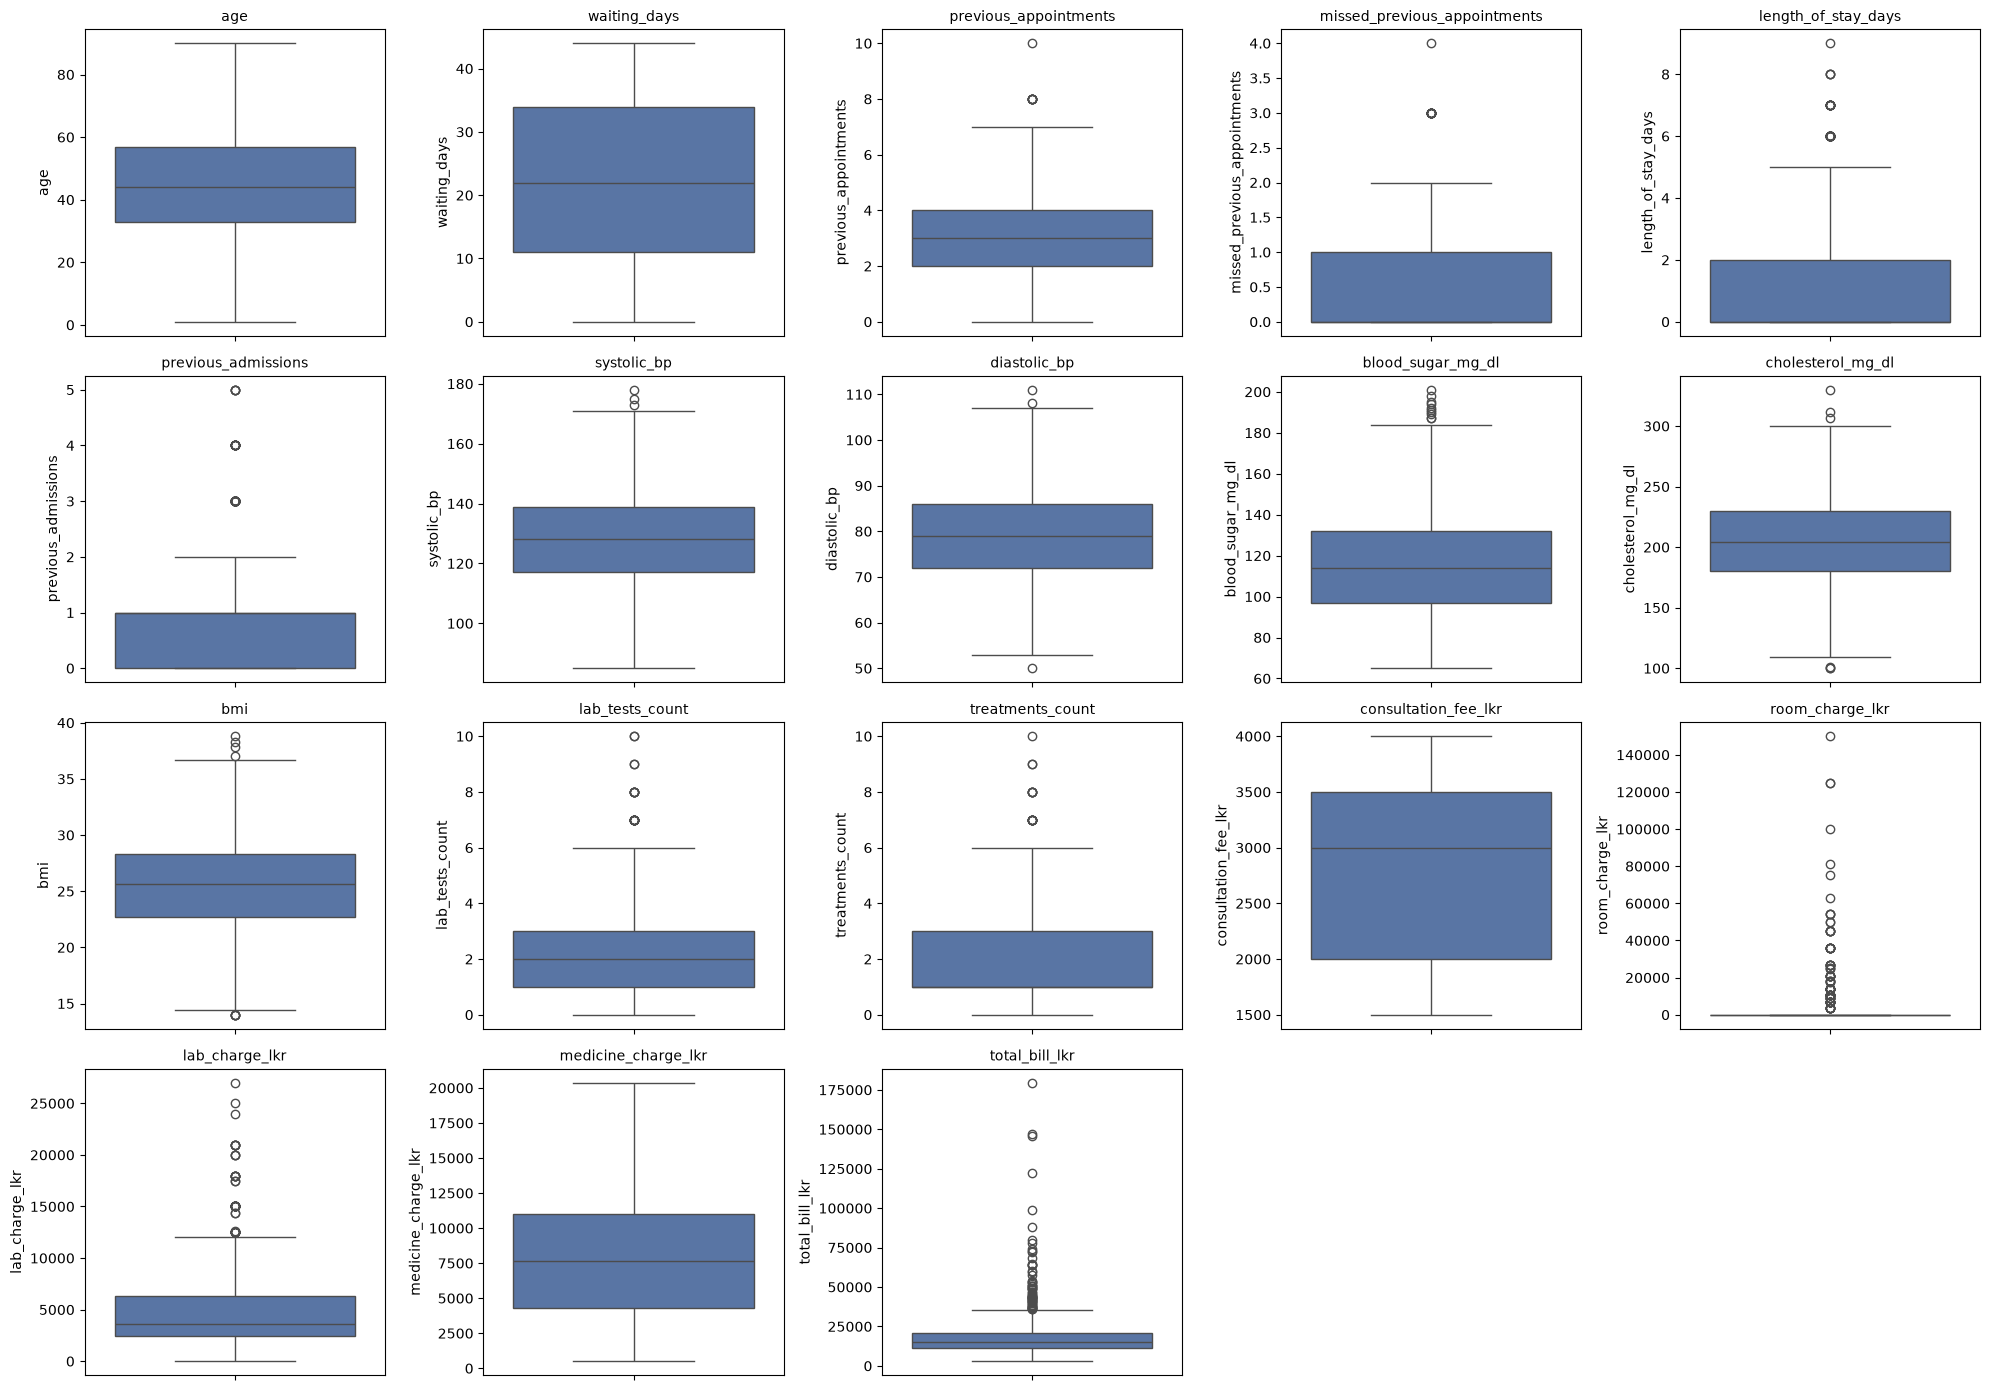

In [24]:
numeric_cols = ['age', 'waiting_days', 'previous_appointments', 'missed_previous_appointments',
                'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp',
                'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count', 'treatments_count',
                'consultation_fee_lkr', 'room_charge_lkr', 'lab_charge_lkr', 'medicine_charge_lkr',
                'total_bill_lkr']

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(col, fontsize=10)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('../outputs/outlier_boxplots.png', dpi=110, bbox_inches='tight')
plt.show()

In [25]:
def iqr_outlier_summary(data, cols):
    rows = []
    for col in cols:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((data[col] < lower) | (data[col] > upper)).sum()
        rows.append({'column': col, 'lower_bound': round(lower, 1), 'upper_bound': round(upper, 1),
                     'n_outliers': n_out, 'pct_outliers': round(n_out / len(data) * 100, 2)})
    return pd.DataFrame(rows).sort_values('pct_outliers', ascending=False)

outlier_summary = iqr_outlier_summary(df, numeric_cols)
outlier_summary

,column,lower_bound,upper_bound,n_outliers,pct_outliers
14,room_charge_lkr,0.0,0.0,94,9.4
15,lab_charge_lkr,-3450.0,12150.0,61,6.1
5,previous_admissions,-1.5,2.5,60,6.0
17,total_bill_lkr,-3760.0,35648.0,59,5.9
4,length_of_stay_days,-3.0,5.0,48,4.8
11,lab_tests_count,-2.0,6.0,23,2.3
3,missed_previous_appointments,-1.5,2.5,17,1.7
12,treatments_count,-2.0,6.0,17,1.7
8,blood_sugar_mg_dl,44.5,184.5,10,1.0
10,bmi,14.3,36.7,9,0.9


In [26]:
print('Age range:', df['age'].min(), '-', df['age'].max())
print('BMI range:', df['bmi'].min(), '-', df['bmi'].max())
print('Any negative charges?', (df[['consultation_fee_lkr','room_charge_lkr','lab_charge_lkr',
                                     'medicine_charge_lkr','total_bill_lkr']] < 0).any().any())
print('Any negative/zero length_of_stay for admitted patients?',
      ((df['admitted']==1) & (df['length_of_stay_days'] <= 0)).sum())

Age range: 1 - 90
BMI range: 14.0 - 38.8
Any negative charges? False
Any negative/zero length_of_stay for admitted patients? 0


the IQR-flagged points sit within clinically or financially plausible ranges. For example the
highest **total_bill_lkr** values occurs becuase of genuinely long ICU stays, not data entry errors, and
**age/bmi** stay within realistic human bounds.

Because they represent real or normal values than impossible or error values, **no outliers are removed or capped**. Removing them would discard
exactly the kind of high-cost, high-risk patients a readmission model most needs to learn from.

The IQR summary is kept as a reference table so the modeling stage is aware of which features are skewed.

## 3.5. Data Cleaning

In [27]:
bill_check = (df['consultation_fee_lkr'] + df['room_charge_lkr'] + df['lab_charge_lkr']
              + df['medicine_charge_lkr'])
print('Rows where total_bill_lkr matches sum of components:', (bill_check == df['total_bill_lkr']).sum(), '/', len(df))

Rows where total_bill_lkr matches sum of components: 1000 / 1000


In [28]:
# missed_previous_appointments cannot exceed previous_appointments.
bad_mask = df['missed_previous_appointments'] > df['previous_appointments']
print('Rows fixed (missed > previous):', bad_mask.sum())
df.loc[bad_mask, 'missed_previous_appointments'] = df.loc[bad_mask, 'previous_appointments']

Rows fixed (missed > previous): 16


In [29]:
# a patient cannot be 'admitted' if their appointment was never attended
# (appointment_status of 'No-Show' or 'Cancelled'). Flag rather than silently drop, since we
# cannot be certain which of the two fields is the error; a flag lets the model / analyst account
# for the inconsistency without losing the row.
df['admission_status_conflict'] = (
    (df['admitted'] == 1) & (df['appointment_status'].isin(['No-Show', 'Cancelled']))
).astype(int)
print('Rows flagged with an admission/appointment_status conflict:', df['admission_status_conflict'].sum())

Rows flagged with an admission/appointment_status conflict: 186


In [30]:
df['appointment_date'] = pd.to_datetime(df['appointment_date'])
df['appointment_month'] = df['appointment_date'].dt.month
df['appointment_dayofweek'] = df['appointment_date'].dt.dayofweek  # 0=Mon

cat_cols_to_clean = ['gender', 'blood_group', 'department', 'diagnosis', 'appointment_status',
                     'room_type', 'payment_status', 'payment_method']
for c in cat_cols_to_clean:
    df[c] = df[c].astype(str).str.strip()

df[cat_cols_to_clean].nunique()

gender                 2
blood_group            8
department             7
diagnosis             10
appointment_status     4
room_type              5
payment_status         3
payment_method         4
dtype: int64

**"missed_previous_appointments" capped at "previous_appointments"**

- This means that if a patient's data says they missed more appointments than they ever had in total (which is impossible), we fix it by setting the missed count equal to the total count. We fixed the number instead of deleting the whole row, so we don't lose data unnecessarily.


**"Admitted"/"appointment_status" conflicts are flagged, not deleted**

- For the 186 rows where a patient is marked "admitted" but also marked as a "No-Show" or "Cancelled", we don't know which of the two fields is wrong. Maybe "admitted" was mistakenly set to 1, or maybe the appointment status was logged wrong. Since we can't tell which one is the mistake, instead of guessing, we just add a new colums(admission_status_conflict) that marks these rows as **"suspicious"**. This way, the row stays in the dataset.

- **Limitation:** this flag turns out to correlate strongly with the target (see Task 04 EDA / SHAP analysis in Task 07). That correlation should be treated with caution — it may reflect the model picking up on a genuine clinical/administrative inconsistency, but it may equally be an artefact of how the synthetic dataset was generated (e.g. conflicting rows being more likely to also carry `readmitted_30_days = 1` by construction, rather than by any real clinical mechanism). Its use as a predictive feature is kept, but this should be flagged as an open question in the report rather than presented as a confirmed clinical finding.


**Categorical text columns are stripped of whitespace**

- Sometimes text data has hidden extra spaces, like "Male " (with a trailing space) instead of "Male". Since "Male " and "Male" are two different categories, if left uncleaned, this creates fake duplicate categories when we later convert text into numbers (one-hot encoding). Stripping whitespace prevents this silent duplication.


**"appointment_date" is parsed to datetime and decomposed into "appointment_month" and "appointment_dayofweek"**

- The raw date like "2025-08-08" isn't very useful to a model as just a text string — it can't learn patterns from it directly. But parts of the date might matter in cases like maybe more patients get readmitted in certain months (seasonal illness patterns), or certain days of the week have different appointment behavior. So instead of keeping the full date, we break it into two more useful, model-friendly pieces such as the month and the day of the week.

## 3.6. Identification and Flagging of Zero Room Charges

In [31]:
condition = (df['length_of_stay_days'] > 0) & (df['room_charge_lkr'] == 0)

df['zero_room_charge_flag'] = condition.astype(int)

print("Affected records:", condition.sum())
print("Percentage:", round(condition.mean() * 100, 2), "%")

display(df.loc[condition, [
    'length_of_stay_days',
    'room_charge_lkr',
    'room_type',
    'zero_room_charge_flag'
]].head())

Affected records: 236
Percentage: 23.6 %


,length_of_stay_days,room_charge_lkr,room_type,zero_room_charge_flag
19,3,0,Unknown,1
21,3,0,Unknown,1
29,2,0,Unknown,1
30,5,0,Unknown,1
32,6,0,Unknown,1


Records with **"length_of_stay_days"** > 0 and **"room_charge_lkr"** = 0 may indicate either a genuinely zero or a no-charge stay. It might also indicate missing or unrecorded billing information.

Since the exact reason cannot be determined from the available dataset, these records were neither removed nor modified. Instead, a binary **"zero_room_charge_flag"** was created to preserve the original information and allow the model to consider this pattern as a potential predictive feature for readmission.

## 3.7. Feature Engineering

In [32]:
df['total_prior_visits'] = df['previous_appointments'] + df['previous_admissions']

df['missed_appointment_rate'] = np.where(
    df['previous_appointments'] > 0,
    df['missed_previous_appointments'] / df['previous_appointments'],
    0
)

def bmi_band(b):
    if b < 18.5: return 'Underweight'
    if b < 25:   return 'Normal'
    if b < 30:   return 'Overweight'
    return 'Obese'
df['bmi_category'] = df['bmi'].apply(bmi_band)

def bp_band(row):
    sys_, dia_ = row['systolic_bp'], row['diastolic_bp']
    if sys_ < 120 and dia_ < 80:
        return 'Normal'
    if sys_ < 140 and dia_ < 90:
        return 'Elevated'
    return 'Hypertensive'
df['bp_category'] = df.apply(bp_band, axis=1)

util_q75 = (df['lab_tests_count'] + df['treatments_count']).quantile(0.75)
df['high_utilisation'] = ((df['lab_tests_count'] + df['treatments_count']) >= util_q75).astype(int)

df['avg_charge_per_treatment'] = df['total_bill_lkr'] / (df['treatments_count'] + 1)

df['is_weekend_appointment'] = df['appointment_dayofweek'].isin([5, 6]).astype(int)

df[['total_prior_visits', 'missed_appointment_rate', 'bmi_category', 'bp_category',
    'high_utilisation', 'avg_charge_per_treatment', 'is_weekend_appointment']].head()

,total_prior_visits,missed_appointment_rate,bmi_category,bp_category,high_utilisation,avg_charge_per_treatment,is_weekend_appointment
0,2,0.000000,Overweight,Elevated,0,3399.0,0
1,3,0.333333,Obese,Elevated,0,2826.0,0
2,8,0.142857,Overweight,Hypertensive,0,6262.0,0
3,1,0.000000,Normal,Elevated,0,8631.0,0
4,5,0.000000,Overweight,Elevated,0,20414.0,0


**Justification for each engineered feature:**
- **"total_prior_visits"** — combines outpatient and inpatient history into one measure of overall prior
  healthcare utilisation, which is a well-known driver of readmission risk.

- **"missed_appointment_rate"** — a *rate* is more comparable across patients than a raw count.

- **"bmi_category"** / **"bp_category"** — convert continuous clinical measurements into clinically meaningful
  bands (standard medical thresholds), which can capture non-linear risk effects that a linear model on
  the raw number would miss, and are easier to interpret.

- **"high_utilisation"** — a simple binary flag for "top quartile" of lab tests + treatments, useful as a
  cheap proxy for how clinically intensive a visit was.

- **"avg_charge_per_treatment"** — This line creates a new feature: average cost per treatment, calculated as total_bill_lkr / (treatments_count + 1).
The +1 just avoids a division-by-zero error for patients with 0 treatments.
Why it's useful: total_bill_lkr alone
can be misleading. A patient might have a huge bill simply because they stayed longer (more room/lab charges), not because their treatments were expensive. Dividing by treatment count removes that "length of stay" effect and isolates how costly each treatment was on average.
The benefit: this gives the model a cleaner signal of which "cost intensity per treatment", instead of a number dominated by how many days someone stayed.

- **"is_weekend_appointment"** — weekend appointments may reflect emergency/urgent care patterns with
  different readmission risk than routine weekday visits.

In [33]:
df.columns.tolist()

['record_id',
 'patient_id',
 'age',
 'gender',
 'blood_group',
 'department',
 'diagnosis',
 'appointment_date',
 'waiting_days',
 'previous_appointments',
 'missed_previous_appointments',
 'appointment_status',
 'admitted',
 'room_type',
 'length_of_stay_days',
 'previous_admissions',
 'systolic_bp',
 'diastolic_bp',
 'blood_sugar_mg_dl',
 'cholesterol_mg_dl',
 'bmi',
 'lab_tests_count',
 'treatments_count',
 'consultation_fee_lkr',
 'room_charge_lkr',
 'lab_charge_lkr',
 'medicine_charge_lkr',
 'total_bill_lkr',
 'payment_status',
 'payment_method',
 'no_show',
 'readmitted_30_days',
 'disease_risk_level',
 'admission_status_conflict',
 'appointment_month',
 'appointment_dayofweek',
 'zero_room_charge_flag',
 'total_prior_visits',
 'missed_appointment_rate',
 'bmi_category',
 'bp_category',
 'high_utilisation',
 'avg_charge_per_treatment',
 'is_weekend_appointment']

## 3.8. Feature Selection

In [34]:
drop_cols = ['record_id', 'patient_id', 'appointment_date', 'no_show', 'disease_risk_level',
             'consultation_fee_lkr', 'room_charge_lkr', 'lab_charge_lkr', 'medicine_charge_lkr']

model_df = df.drop(columns=drop_cols)
print(model_df.shape)
model_df.columns.tolist()

(1000, 35)


['age',
 'gender',
 'blood_group',
 'department',
 'diagnosis',
 'waiting_days',
 'previous_appointments',
 'missed_previous_appointments',
 'appointment_status',
 'admitted',
 'room_type',
 'length_of_stay_days',
 'previous_admissions',
 'systolic_bp',
 'diastolic_bp',
 'blood_sugar_mg_dl',
 'cholesterol_mg_dl',
 'bmi',
 'lab_tests_count',
 'treatments_count',
 'total_bill_lkr',
 'payment_status',
 'payment_method',
 'readmitted_30_days',
 'admission_status_conflict',
 'appointment_month',
 'appointment_dayofweek',
 'zero_room_charge_flag',
 'total_prior_visits',
 'missed_appointment_rate',
 'bmi_category',
 'bp_category',
 'high_utilisation',
 'avg_charge_per_treatment',
 'is_weekend_appointment']

- **"record_id"**, **"patient_id"** — They identify the patient/record but don't provide meaningful predictive information.

- **"appointment_date"** — decomposed into **"appointment_month"** / **"appointment_dayofweek"**, which
  capture the reusable signal in the date without the model memorising specific calendar dates.

- **"no_show"**, **"disease_risk_level"** — targets for the other two prediction tasks in this dataset.

- **"consultation_fee_lkr"**, **"room_charge_lkr"**, **"lab_charge_lkr"**, **"medicine_charge_lkr"** — Because they sum to **"total_bill_lkr"**, making them perfectly collinear with it. Keeping **"total_bill_lkr"** alone keeps the same financial information without duplications.

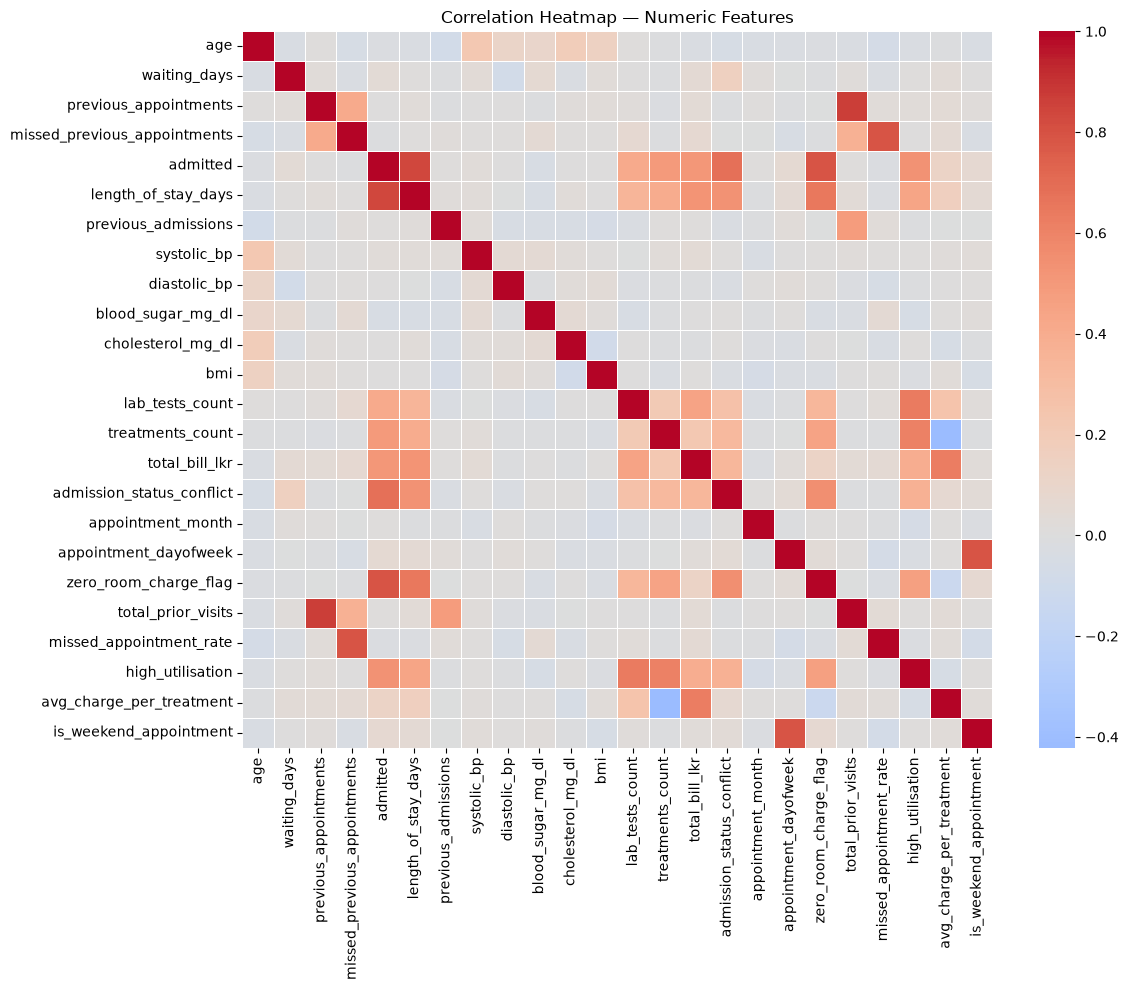

In [35]:
num_features = model_df.select_dtypes(include=[np.number]).drop(columns=['readmitted_30_days'])
corr = num_features.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.4)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()

In [36]:
high_corr_pairs = (corr.abs()
                    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
                    .stack()
                    .sort_values(ascending=False))
high_corr_pairs[high_corr_pairs > 0.6]

previous_appointments         total_prior_visits           0.868926
admitted                      length_of_stay_days          0.834099
                              zero_room_charge_flag        0.791935
appointment_dayofweek         is_weekend_appointment       0.790624
missed_previous_appointments  missed_appointment_rate      0.790143
admitted                      admission_status_conflict    0.681122
length_of_stay_days           zero_room_charge_flag        0.652039
lab_tests_count               high_utilisation             0.636802
total_bill_lkr                avg_charge_per_treatment     0.622963
treatments_count              high_utilisation             0.607172
dtype: float64

In [37]:
target_corr = model_df.select_dtypes(include=[np.number]).corr()['readmitted_30_days'].drop('readmitted_30_days')
target_corr.sort_values(key=abs, ascending=False)

admitted                        0.829240
length_of_stay_days             0.734844
zero_room_charge_flag           0.667900
admission_status_conflict       0.573090
total_bill_lkr                  0.453418
high_utilisation                0.438295
treatments_count                0.386763
lab_tests_count                 0.367357
avg_charge_per_treatment        0.150580
previous_admissions             0.064067
missed_appointment_rate        -0.059059
is_weekend_appointment          0.054463
missed_previous_appointments   -0.052363
appointment_month              -0.050978
appointment_dayofweek           0.038986
age                             0.034263
systolic_bp                     0.026746
cholesterol_mg_dl               0.026569
blood_sugar_mg_dl              -0.019859
previous_appointments          -0.018554
total_prior_visits              0.015488
waiting_days                    0.014947
bmi                             0.013295
diastolic_bp                   -0.001486
Name: readmitted

A correlation heatmap and a list of feature pairs with correlation above 0.6 were used for two purposes:

(1) to check if any other numeric features are still redundant with each other, beyond the four charge columns already removed

(2) to see which numeric features have the strongest linear relationship with the target variable — useful context before modeling.

**Result**:

No remaining feature pairs exceeded the 0.6 correlation threshold, confirming that removing the four charge columns was enough to eliminate the major redundancy in the numeric data.

**Why no more columns were dropped**:

Moderate correlation (below 0.6) isn't a strong enough reason to remove a feature-tree-based models (like Random Forest, XGBoost) aren't affected by correlated features at all, and regularized linear models (like Ridge/Lasso Logistic Regression) can handle moderate correlation without becoming unstable. Since this is still an early, exploratory stage, dropping more columns now risks throwing away genuinely useful signal for a very small, uncertain benefit.

## 3.9. Feature Encoding

In [38]:
bmi_order = {'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obese': 3}
bp_order = {'Normal': 0, 'Elevated': 1, 'Hypertensive': 2}

model_df['bmi_category'] = model_df['bmi_category'].map(bmi_order)
model_df['bp_category'] = model_df['bp_category'].map(bp_order)

print('Ordinal encoding check:')
print(model_df[['bmi_category', 'bp_category']].dtypes)
print(model_df[['bmi_category', 'bp_category']].head())

Ordinal encoding check:
bmi_category    int64
bp_category     int64
dtype: object
   bmi_category  bp_category
0             2            1
1             3            1
2             2            2
3             1            1
4             2            1


In [39]:
nominal_cols = ['gender', 'blood_group', 'department', 'diagnosis',
                'appointment_status', 'room_type', 'payment_status', 'payment_method']

model_df_encoded = pd.get_dummies(model_df, columns=nominal_cols, drop_first=True)

print('Shape after one-hot encoding:', model_df_encoded.shape)
model_df_encoded.head()

Shape after one-hot encoding: (1000, 62)


,age,waiting_days,previous_appointments,missed_previous_appointments,admitted,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,...,appointment_status_Scheduled,room_type_ICU,room_type_Not Admitted,room_type_Private Room,room_type_Unknown,payment_status_Partially Paid,payment_status_Unpaid,payment_method_Cash,payment_method_Insurance,payment_method_Online
0,53,10,1,0,0,0,1,127,75,117,...,False,False,True,False,False,False,False,False,True,False
1,26,2,3,1,0,0,0,130,73,136,...,False,False,True,False,False,False,False,False,True,False
2,22,22,7,1,0,0,1,141,64,90,...,False,False,True,False,False,False,True,False,True,False
3,44,16,1,0,0,0,0,124,82,126,...,False,False,True,False,False,False,False,False,False,True
4,51,12,4,0,0,0,1,119,81,65,...,True,False,True,False,False,False,False,True,False,False


In [40]:
# Step 3: Convert True/False dummy columns to 0/1 integers (safer for scikit-learn/XGBoost)
bool_cols = model_df_encoded.select_dtypes(include='bool').columns
model_df_encoded[bool_cols] = model_df_encoded[bool_cols].astype(int)

print('Final encoded dataset shape:', model_df_encoded.shape)
print('\nColumn dtypes summary:')
print(model_df_encoded.dtypes.value_counts())

Final encoded dataset shape: (1000, 62)

Column dtypes summary:
int64      57
float64     3
int32       2
Name: count, dtype: int64


## 3.10. Train/Test Split and Feature scaling

In [41]:
X = model_df_encoded.drop(columns=['readmitted_30_days', 'high_utilisation'])
y = model_df_encoded['readmitted_30_days']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Recompute high_utilisation without leakage: threshold derived from
# training data only, then applied unchanged to the test set.
util_q75 = (X_train['lab_tests_count'] + X_train['treatments_count']).quantile(0.75)

X_train['high_utilisation'] = ((X_train['lab_tests_count'] + X_train['treatments_count']) >= util_q75).astype(int)
X_test['high_utilisation'] = ((X_test['lab_tests_count'] + X_test['treatments_count']) >= util_q75).astype(int)

print('high_utilisation threshold (train-only q75):', util_q75)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train class balance:\n', y_train.value_counts(normalize=True).round(3))
print('Test class balance:\n', y_test.value_counts(normalize=True).round(3))

high_utilisation threshold (train-only q75): 5.25
Train shape: (800, 61)  Test shape: (200, 61)
Train class balance:
 readmitted_30_days
0    0.748
1    0.252
Name: proportion, dtype: float64
Test class balance:
 readmitted_30_days
0    0.745
1    0.255
Name: proportion, dtype: float64


## 3.10.1. Save Test-Set Demographics for Fairness Assessment (Task 07)

`X_train`/`X_test` are saved later with `index=False`, which discards which original patient each row belongs to. Since `model_df` (pre-encoding) still has readable `gender`/`age`/`department` columns aligned to the same row order as `X_test` (train_test_split preserves the original index, and no reordering happens between here and export), this is the point to capture them — needed for the fairness/subgroup analysis in Task 07, not the model itself.

In [42]:
test_demographics = model_df.loc[X_test.index, ['gender', 'age', 'department']].copy()

test_demographics['age_group'] = pd.cut(
    test_demographics['age'],
    bins=[0, 30, 50, 70, 120],
    labels=['<30', '30-49', '50-69', '70+']
)

test_demographics.to_csv('../data/processed/test_demographics.csv', index=False)
print('Saved test_demographics.csv, shape:', test_demographics.shape)
test_demographics.head()

Saved test_demographics.csv, shape: (200, 4)


,gender,age,department,age_group
79,Male,16,General Medicine,<30
325,Male,50,Neurology,30-49
551,Female,15,Neurology,<30
342,Male,43,Cardiology,30-49
562,Male,24,General Medicine,<30


**"high_utilisation"** was originally computed on the full dataset (Task 02 EDA version), which risked test-set leakage since the quartile threshold would be informed by test rows. For the modelling pipeline, this was corrected by deriving the threshold from the training set only and applying it unchanged to the test set.

The split is stratified on **"readmitted_30_days"** so the train and test sets both
preserve the same ~25% positive-class rate seen in the raw data (see Data Quality discussion), which
matters for a moderately imbalanced target. The split is done **before** scaling so that the scaler is
fit only on training data in the next step, avoiding test-set information leaking into the transformation.

In [43]:
continuous_cols = ['age', 'waiting_days', 'previous_appointments', 'missed_previous_appointments',
                   'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp',
                   'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count', 'treatments_count',
                   'total_bill_lkr', 'total_prior_visits', 'missed_appointment_rate',
                   'avg_charge_per_treatment', 'appointment_month', 'appointment_dayofweek']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

X_train_scaled[continuous_cols].describe().T[['mean', 'std']].round(2)

,mean,std
age,-0.0,1.0
waiting_days,0.0,1.0
previous_appointments,0.0,1.0
missed_previous_appointments,0.0,1.0
length_of_stay_days,-0.0,1.0
previous_admissions,-0.0,1.0
systolic_bp,0.0,1.0
diastolic_bp,-0.0,1.0
blood_sugar_mg_dl,0.0,1.0
cholesterol_mg_dl,0.0,1.0


only genuinely continuous/count columns are scaled; the one-hot dummy columns and
binary flags ("admitted", "high_utilisation", "is_weekend_appointment", "admission_status_conflict") are
deliberately left unscaled since they are already on a meaningful 0/1 scale and scaling them would distort
that meaning. "StandardScaler" (zero mean, unit variance) is used rather than min-max scaling because
several continuous features (e.g. "total_bill_lkr", "avg_charge_per_treatment") are right-skewed with
legitimate high-value outliers (retained per the Outlier Identification decision above); standardisation
is less sensitive to those extreme values than a min-max range. The scaler is **fit on the training set
only** and applied to the test set with `.transform()`, preventing test-set leakage into the scaling
parameters.

## 3.11. Export preprocessed data for EDA

In [44]:
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
X_train_scaled.to_csv('../data/processed/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test_scaled.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print('Files saved:')
for f in ['X_train.csv','X_test.csv','X_train_scaled.csv','X_test_scaled.csv','y_train.csv','y_test.csv']:
    print(' -', '../data/processed',f)

Files saved:
 - ../data/processed X_train.csv
 - ../data/processed X_test.csv
 - ../data/processed X_train_scaled.csv
 - ../data/processed X_test_scaled.csv
 - ../data/processed y_train.csv
 - ../data/processed y_test.csv


In [45]:
import joblib

joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(model_df_encoded.drop(columns=['readmitted_30_days']).columns.tolist(), '../models/model_columns.pkl')

joblib.dump(continuous_cols, '../models/scaled_columns.pkl')
joblib.dump(nominal_cols, '../models/nominal_cols.pkl')

joblib.dump(util_q75, '../models/high_utilisation_threshold.pkl')


['../models/high_utilisation_threshold.pkl']

## 3.12. Export **"model_df"** for Task 04 (EDA)

Saved separately so Task 04 can be run as its own notebook without re-running Tasks 02-03.

In [46]:
model_df.to_csv('../data/processed/model_df.csv', index=False)
print('Saved model_df.csv, shape:', model_df.shape)

Saved model_df.csv, shape: (1000, 35)
